<a href="https://colab.research.google.com/github/TTQuaye11/Quayenortey_Tetteh_Lab0/blob/main/lab0_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Tue Jun  2 20:23:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Exercise 4

In [8]:
#Task 1
import numpy as np
arr1 = np.ones((5,5))
arr1[1:4,1:4] = np.zeros((3,3))
print(arr1)

#Task 2
np.random.seed(42)
random_data = np.random.randn(100, 3)
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print(normalized)

#Task 3
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
print(true_theta)
print(theta_hat)


[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818

Exercise 5

In [30]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

#Task 1
print(df.info())
print(df.isnull().sum())
df["exam_score"] = df["exam_score"].fillna(df["exam_score"].mean())
df["hours_studied"] = df["hours_studied"].fillna(df["hours_studied"].median())
print(df.isnull().sum())

#Task 2
df_meanscores = df.groupby("major")["exam_score"].agg(["mean"])
print(df_meanscores)
df_sorted = df_meanscores.sort_values("mean",ascending= False)
print(df_sorted.head(1),"is the major with the highest average score.")

correlation = df['hours_studied'].corr(df['exam_score'])
print(f"\nCorrelation between Hours Studied and Exam Score: {correlation:.4f}")
def categorize(score):
  if score > 90:
    return 'Excellent'
  elif score >= 80:
      return 'Good'
  elif score >= 70:
    return 'Average'
  else:
    return 'Needs Improvement'
df['performance'] = df['exam_score'].apply(categorize)
print(df.info())

#Task 3

group_analysis = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)
print(group_analysis)


df_average = df.groupby('student_id')['exam_score'].mean().reset_index()
df_average.columns = ['student_id', 'mean']
df_sorted_scores = df_average.sort_values('mean', ascending=False)
print(df_sorted_scores.head(5))

pivot = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)
print(pivot)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: int64
              mean
major             
Biology  75.503428


Exercise 6

Text(0.5, 1.0, 'Exam Scores Data')

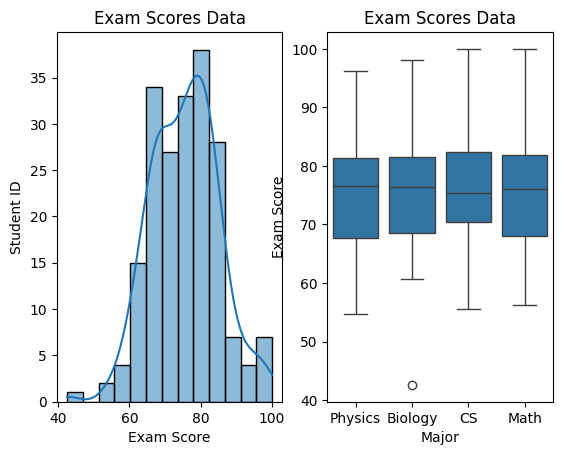

In [6]:
#Task 1
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200


data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}
df = pd.DataFrame(data)

plt.subplot(1,2,1)
sns.histplot(df['exam_score'], kde=True)
plt.xlabel('Exam Score')
plt.ylabel('Student ID')
plt.title('Exam Scores Data')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='major', y='exam_score')
plt.xlabel('Major')
plt.ylabel('Exam Score')
plt.title('Exam Scores Data')



Text(0.5, 1.0, 'Hours Studied vs Exam Score')

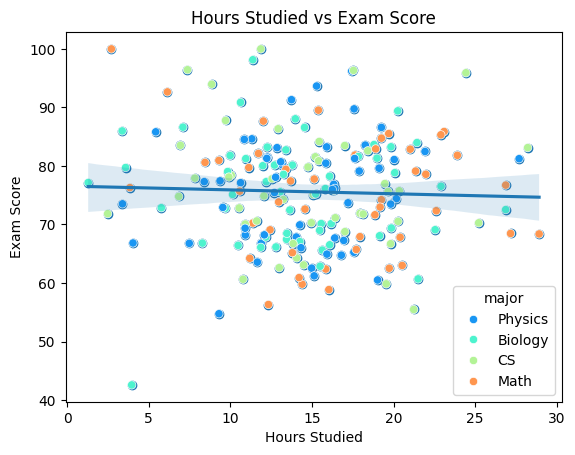

In [9]:
#Task 2
plt.scatter(df['hours_studied'], df['exam_score'])
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')

sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='major', palette= 'rainbow')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')

sns.regplot(data=df, x='hours_studied', y='exam_score', scatter= False)
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')


Text(0.5, 1.0, 'Correlation Heatmap')

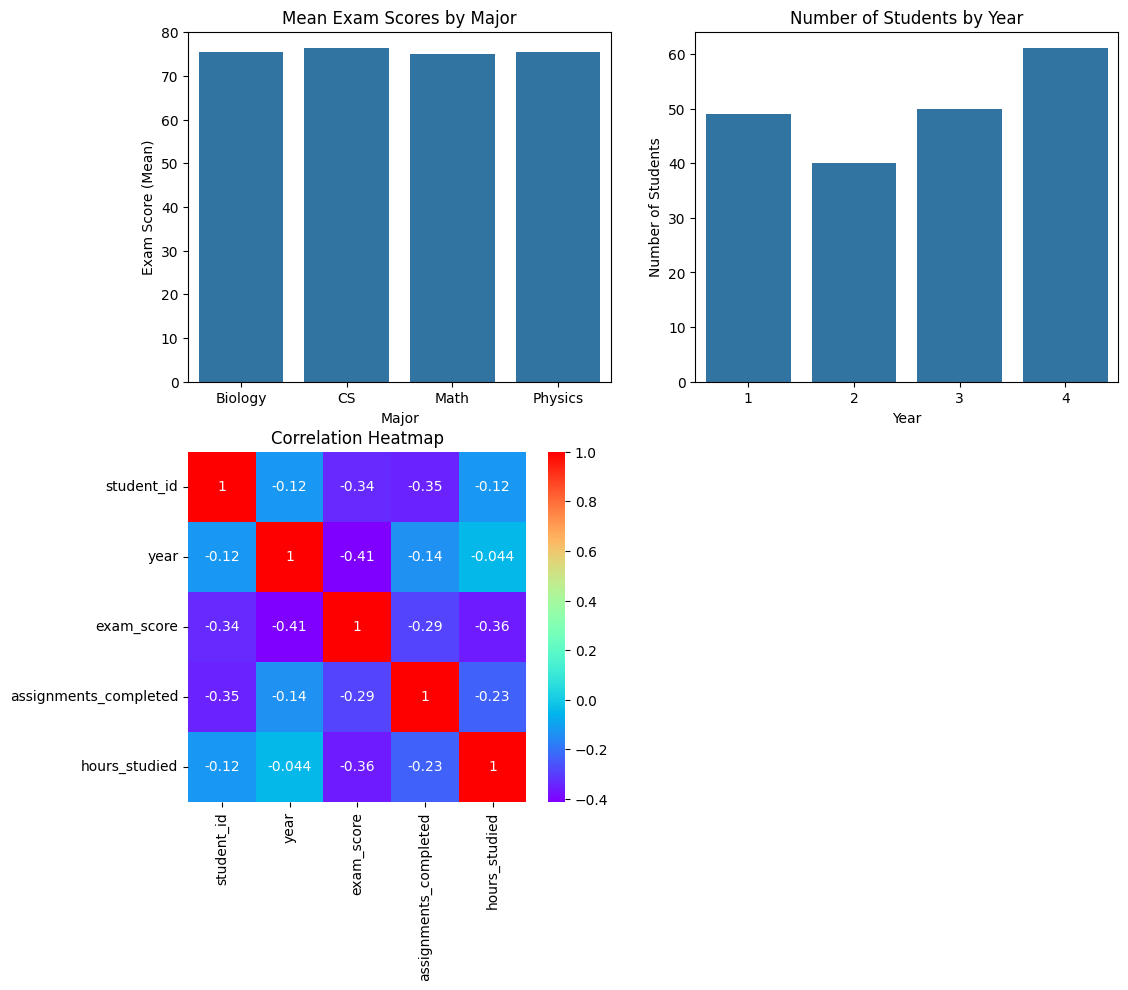

In [14]:
#Task 3
plt.figure(figsize=(12, 10))
plt.subplot(2,2,1)
sns.barplot(df.groupby('major')['exam_score'].mean())
plt.xlabel('Major')
plt.ylabel('Exam Score (Mean)')
plt.title('Mean Exam Scores by Major')

plt.subplot(2,2,2)
sns.countplot(data = df, x= 'year')
plt.xlabel('Year')
plt.ylabel('Number of Students')
plt.title('Number of Students by Year')

plt.subplot(2,2,3)
matrix = df.select_dtypes(include='number').corr()

sns.heatmap(matrix.corr(), annot = True, cmap = 'rainbow')
plt.title('Correlation Heatmap')

In [2]:
#Task 7
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})


max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (
    customers['purchase_frequency'] / max_frequency
)


customers['CLV'] = (
    customers['purchase_frequency'] *
    customers['avg_purchase_value'] *
    (1 + customers['churn_risk'])
)


bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']

customers['age_group'] = pd.cut(
    customers['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)


age_group_summary = customers.groupby('age_group').agg(
    number_of_customers=('age', 'count'),
    average_income=('income', 'mean'),
    average_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
)

print(age_group_summary)


clv_threshold = customers['CLV'].quantile(0.90)

top_10_customers = customers[
    customers['CLV'] >= clv_threshold
]

           number_of_customers  average_income  average_CLV      total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683


/tmp/ipykernel_1543/2918502007.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_summary = customers.groupby('age_group').agg(
